# Toxic Search Training Notebook

This notebook trains a semantic encoder for toxic content search using triplet loss and sentence-transformers.

## Architecture

- **Base Model**: `paraphrase-multilingual-mpnet-base-v2`
- **Training**: Triplet loss with contrastive learning
- **Output**: Fine-tuned encoder for semantic similarity search
- **Vector Store**: Qdrant for efficient retrieval

## 1. Setup and Installation

In [21]:
# Install dependencies (if needed)
# !pip install sentence-transformers qdrant-client loguru pandas scikit-learn tqdm umap-learn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 29.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:0000:0100:01


In [2]:
import sys
import os
from pathlib import Path
import warnings

# Add project root and src to path
project_root = Path.cwd().parent
src_path = project_root / "src"

# Add both to path
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(src_path))

warnings.filterwarnings('ignore')

print(f"Project root: {project_root}")
print(f"Src path: {src_path}")
print(f"Src exists: {src_path.exists()}")
print(f"Python version: {sys.version}")

Project root: /indonesian-hate-speech-detection-main
Src path: /indonesian-hate-speech-detection-main/src
Src exists: True
Python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]


In [3]:
import numpy as np
import pandas as pd
import torch
from loguru import logger
from tqdm.auto import tqdm

from toxic_search.models.encoder import ToxicEncoder, load_encoder
from toxic_search.data.loader import load_dataset, split_dataset
from toxic_search.data.triplets import TripletGenerator, Triplet
from toxic_search.training.trainer import train
from toxic_search.training.evaluator import evaluate_retrieval
from toxic_search.config import get_config
from toxic_search.utils import setup_logging

# Setup logging
setup_logging()

print(f"✅ All imports successful")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🚀 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

✅ All imports successful
🔥 PyTorch version: 2.9.1+cu128
🚀 CUDA available: True
🎮 GPU: NVIDIA GeForce RTX 5090


## 2. Configuration

In [4]:
# Load configuration from pyproject.toml
config = get_config()

# Display configuration
print("📋 Configuration:")
print(f"  Base Model: {config.model.base_model}")
print(f"  Max Sequence Length: {config.model.max_seq_length}")
print(f"  Embedding Dimension: {config.model.embedding_dim}")
print(f"  Distance Metric: {config.model.distance_metric}")
print(f"\n  Training:")
print(f"    Batch Size: {config.training.batch_size}")
print(f"    Epochs: {config.training.num_epochs}")
print(f"    Learning Rate: {config.training.learning_rate}")
print(f"    Margin: {config.training.margin}")
print(f"    FP16: {config.training.fp16}")

📋 Configuration:
  Base Model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  Max Sequence Length: 128
  Embedding Dimension: 768
  Distance Metric: cosine

  Training:
    Batch Size: 32
    Epochs: 3
    Learning Rate: 2e-05
    Margin: 0.5
    FP16: True


In [5]:
# Paths
DATA_PATH = project_root / "dataset" / "indonesian_hate_speech.csv"
OUTPUT_PATH = project_root / "models" / "toxic_search_finetuned"

# Ensure output directory exists
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(f"📂 Data path: {DATA_PATH}")
print(f"💾 Output path: {OUTPUT_PATH}")

📂 Data path: /indonesian-hate-speech-detection-main/dataset/indonesian_hate_speech.csv
💾 Output path: /indonesian-hate-speech-detection-main/models/toxic_search_finetuned


## 3. Load and Explore Dataset

In [6]:
# Load dataset
print("📊 Loading dataset...")
df = load_dataset(DATA_PATH, text_column="text", label_column="labels")

# Display basic statistics
print(f"\n📈 Dataset Statistics:")
print(f"  Total samples: {len(df):,}")
print(f"  Toxic samples: {df['labels'].sum():,} ({df['labels'].mean():.1%})")
print(f"  Non-toxic samples: {(1-df['labels']).sum():,} ({(1-df['labels']).mean():.1%})")

# Show sample data
print(f"\n📝 Sample Data:")
df.head()

2025-11-24 11:43:13 | INFO     | toxic_search.data.loader:load_dataset - Loaded 14306 samples from /indonesian-hate-speech-detection-main/dataset/indonesian_hate_speech.csv


📊 Loading dataset...

📈 Dataset Statistics:
  Total samples: 14,306
  Toxic samples: 6,050 (42.3%)
  Non-toxic samples: 8,256 (57.7%)

📝 Sample Data:


,text,labels,source,dataset,nb_annotators
0,@USER.wood17 knp lo gak berani bersumpah dan b...,1,Instagram,ID_instagram,3
1,"haha, somad somad. Muka dekil otak 0% , kok ya...",1,Instagram,ID_instagram,3
2,"hahaha, kaum sableng 212 kl berita begini mrk ...",1,Instagram,ID_instagram,3
3,"hahaha, makin stress aja ni umat sableng, dlu...",1,Instagram,ID_instagram,3
4,HIDUP PSI = partai SAMPAH indonesia..... ...,1,Instagram,ID_instagram,3


📏 Text Length Statistics:
        text_length    word_count
count  14306.000000  14306.000000
mean     112.587725     17.015099
std       68.069580     10.120852
min        4.000000      1.000000
25%       59.000000      9.000000
50%       99.000000     15.000000
75%      147.000000     22.000000
max      561.000000     55.000000


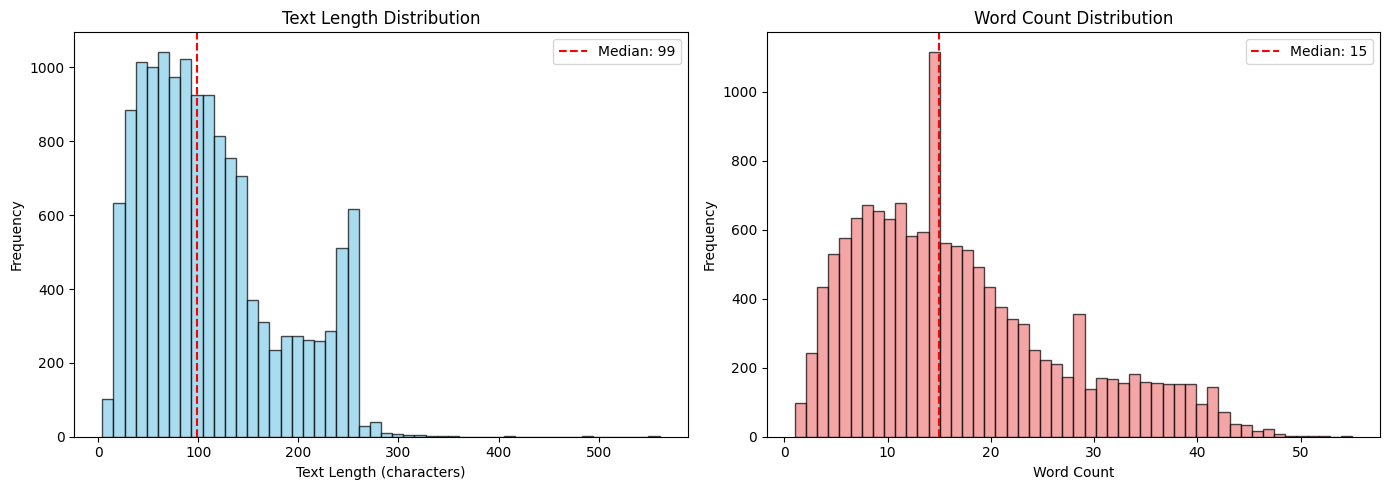

In [7]:
# Analyze text lengths
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("📏 Text Length Statistics:")
print(df[['text_length', 'word_count']].describe())

# Visualize distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length distribution
axes[0].hist(df['text_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(df['text_length'].median(), color='red', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution')
axes[0].legend()

# Word count distribution
axes[1].hist(df['word_count'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Data Splitting

In [8]:
# Split dataset
print("🔀 Splitting dataset...")
train_df, val_df, test_df = split_dataset(
    df,
    train_size=0.8,
    val_size=0.1,
    test_size=0.1,
    stratify_column="labels",
    random_state=42
)

print(f"\n📋 Split Summary:")
print(f"  Train: {len(train_df):,} samples ({train_df['labels'].mean():.1%} toxic)")
print(f"  Val:   {len(val_df):,} samples ({val_df['labels'].mean():.1%} toxic)")
print(f"  Test:  {len(test_df):,} samples ({test_df['labels'].mean():.1%} toxic)")

2025-11-24 11:43:14 | INFO     | toxic_search.data.loader:split_dataset - Split: train=11444, val=1431, test=1431


🔀 Splitting dataset...

📋 Split Summary:
  Train: 11,444 samples (42.3% toxic)
  Val:   1,431 samples (42.3% toxic)
  Test:  1,431 samples (42.3% toxic)


## 5. Generate Training Triplets

Triplets consist of:
- **Anchor**: A toxic/non-toxic text
- **Positive**: Another text with the same label
- **Negative**: A text with a different label

The model learns to bring anchor and positive closer while pushing negative away.

In [9]:
# Generate training triplets
print("🔄 Generating training triplets...")
train_generator = TripletGenerator(
    train_df,
    text_column="text",
    label_column="labels"
)

train_triplets = []
for batch in tqdm(train_generator.generate(batch_size=1000), desc="Generating triplets"):
    train_triplets.extend(batch)

print(f"\n✅ Generated {len(train_triplets):,} training triplets")

# Generate validation triplets
print("🔄 Generating validation triplets...")
val_generator = TripletGenerator(
    val_df,
    text_column="text",
    label_column="labels"
)

val_triplets = []
for batch in val_generator.generate(batch_size=1000):
    val_triplets.extend(batch)

print(f"✅ Generated {len(val_triplets):,} validation triplets")

🔄 Generating training triplets...


Generating triplets: 0it [00:00, ?it/s]


✅ Generated 11,444 training triplets
🔄 Generating validation triplets...
✅ Generated 1,431 validation triplets


In [10]:
# Inspect sample triplets
print("🔍 Sample Triplets:\n")
for i, triplet in enumerate(train_triplets[:3]):
    print(f"Triplet {i+1}:")
    print(f"  Anchor:   {triplet.anchor[:100]}...")
    print(f"  Positive: {triplet.positive[:100]}...")
    print(f"  Negative: {triplet.negative[:100]}...")
    print()

🔍 Sample Triplets:

Triplet 1:
  Anchor:   Gw ngerti kalo abang gw mau ngobrolin ini udah ngumpulin keberanian dulu sampe agak gemeter pas ngom...
  Positive: Jika persoalan pemimpin hanya dikaitkan dengan lisan, maka apa bedanya gubernur dengan anak-anak? #M...
  Negative: Cina telah menguasai ekonomi dan media massa. Ayo usir dari Indonesia...

Triplet 2:
  Anchor:   USER kyknya mulai kumat lg ya penyakitnya. Putus molo.. mau naikin tarif lg ya? Kacrut?'...
  Positive: USER Sa, nama akunnya kok kyk ndak asing ya? Apa cmn prasaanku doang USER'...
  Negative: Ucril halang2 i Pembubaran HTI! Mau lengserkan Jokowi USER USER USER USER USER...

Triplet 3:
  Anchor:   USER Kalau ngepal kntl itu lo enak'...
  Positive: USER kayak memegang, bukan mucikari'...
  Negative: Sesungguhnya ketika harga daging pernah tembus di angka 200 ribu per kilo pemerintah Jokowi tlh gaga...



## 6. Load Base Encoder Model

In [11]:
# Load pretrained encoder
print("🔄 Loading base encoder model...")
encoder = load_encoder(
    model_name_or_path=config.model.base_model,
    max_seq_length=config.model.max_seq_length
)

print(f"\n✅ Encoder loaded:")
print(f"  Model: {config.model.base_model}")
print(f"  Embedding dim: {encoder.embedding_dim}")
print(f"  Device: {encoder.device}")

2025-11-24 11:43:28 | INFO     | toxic_search.models.encoder:load_encoder - Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


🔄 Loading base encoder model...


2025-11-24 11:43:32 | INFO     | toxic_search.models.encoder:load_encoder - Encoder loaded: dim=768, device=cuda



✅ Encoder loaded:
  Model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  Embedding dim: 768
  Device: cuda


In [12]:
# Test encoding
sample_texts = [
    "Kamu sangat bodoh dan tidak berguna",
    "Terima kasih atas bantuan yang luar biasa"
]

print("🧪 Testing encoder with sample texts:")
embeddings = encoder.encode(sample_texts, show_progress=True)
print(f"\n  Embeddings shape: {embeddings.shape}")
print(f"  Embeddings dtype: {embeddings.dtype}")

# Compute cosine similarity
from torch.nn.functional import cosine_similarity
similarity = cosine_similarity(embeddings[0:1], embeddings[1:2])
print(f"  Cosine similarity: {similarity.item():.4f}")

🧪 Testing encoder with sample texts:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


  Embeddings shape: torch.Size([2, 768])
  Embeddings dtype: torch.float32
  Cosine similarity: 0.1308


## 7. Train the Encoder

In [13]:
# Train the model
print("🚀 Starting training...\n")
print("=" * 80)

trained_encoder = train(
    encoder=encoder,
    train_triplets=train_triplets,
    val_triplets=val_triplets,
    output_path=OUTPUT_PATH
)

print("\n" + "=" * 80)
print("✅ Training completed!")

2025-11-24 11:43:32 | INFO     | toxic_search.training.trainer:train - Training configuration:
2025-11-24 11:43:32 | INFO     | toxic_search.training.trainer:train -   Batch size: 32
2025-11-24 11:43:32 | INFO     | toxic_search.training.trainer:train -   Epochs: 3
2025-11-24 11:43:32 | INFO     | toxic_search.training.trainer:train -   Learning rate: 2e-05
2025-11-24 11:43:32 | INFO     | toxic_search.training.trainer:train -   Total steps: 1074
2025-11-24 11:43:32 | INFO     | toxic_search.training.trainer:train -   Warmup steps: 100
2025-11-24 11:43:32 | INFO     | toxic_search.training.trainer:train -   FP16: True


🚀 Starting training...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.278200
1000,0.103200


2025-11-24 11:45:39 | INFO     | toxic_search.training.trainer:train - Training complete. Saving model to /indonesian-hate-speech-detection-main/models/toxic_search_finetuned
2025-11-24 11:45:40 | INFO     | toxic_search.training.trainer:train - Files saved: ['config_sentence_transformers.json', 'config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'tokenizer.json', 'sentence_bert_config.json', '1_Pooling', 'modules.json', 'README.md']
2025-11-24 11:45:40 | INFO     | toxic_search.training.trainer:train - Model successfully saved to /indonesian-hate-speech-detection-main/models/toxic_search_finetuned



✅ Training completed!


## 8. Evaluate the Model

In [14]:
# Generate test triplets for evaluation
print("🔄 Generating test triplets for evaluation...")
test_generator = TripletGenerator(
    test_df,
    text_column="text",
    label_column="labels"
)

test_triplets = []
for batch in test_generator.generate(batch_size=1000):
    test_triplets.extend(batch)

print(f"✅ Generated {len(test_triplets):,} test triplets")

🔄 Generating test triplets for evaluation...
✅ Generated 1,431 test triplets


In [15]:
# Encode all test anchors
print("🔄 Encoding test data...")
anchor_texts = [t.anchor for t in test_triplets[:500]]  # Use subset for speed
anchor_embeddings = trained_encoder.encode(anchor_texts, batch_size=32, show_progress=True)

# Create corpus (all unique texts in test set)
corpus_texts = test_df['text'].unique().tolist()[:1000]  # Limit corpus size
corpus_embeddings = trained_encoder.encode(corpus_texts, batch_size=32, show_progress=True)
corpus_labels = [test_df[test_df['text'] == text]['labels'].iloc[0] for text in corpus_texts]

print(f"\n  Anchor embeddings: {anchor_embeddings.shape}")
print(f"  Corpus embeddings: {corpus_embeddings.shape}")

🔄 Encoding test data...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]


  Anchor embeddings: torch.Size([500, 768])
  Corpus embeddings: torch.Size([1000, 768])


In [16]:
# Perform retrieval evaluation
print("🔍 Evaluating retrieval quality...\n")

# Compute similarities and retrieve top-k
from torch.nn.functional import cosine_similarity as cos_sim

query_labels = [test_df[test_df['text'] == text]['labels'].iloc[0] for text in anchor_texts]
retrieved_labels = []

k = 20  # Retrieve top-20
for anchor_emb in tqdm(anchor_embeddings, desc="Retrieving"):
    # Compute similarities
    similarities = cos_sim(anchor_emb.unsqueeze(0), corpus_embeddings)
    
    # Get top-k indices
    top_k_indices = similarities.argsort(descending=True)[:k]
    
    # Get labels
    retrieved = [corpus_labels[idx] for idx in top_k_indices.cpu().numpy()]
    retrieved_labels.append(retrieved)

# Evaluate
metrics = evaluate_retrieval(
    query_labels=query_labels,
    retrieved_labels=retrieved_labels,
    k_values=[1, 5, 10, 20]
)

print("\n📊 Retrieval Metrics:")
print("=" * 50)
for metric, value in metrics.items():
    print(f"  {metric}: {value:.4f}")

🔍 Evaluating retrieval quality...



Retrieving:   0%|          | 0/500 [00:00<?, ?it/s]

2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics - Retrieval Metrics:
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   precision@1: 1.0000
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   precision@5: 0.8780
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   precision@10: 0.8596
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   precision@20: 0.8545
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   recall@1: 0.0028
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   recall@5: 0.0121
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   recall@10: 0.0237
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   recall@20: 0.0471
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   MAP: 0.9257
2025-11-24 11:45:42 | INFO     | toxic_search.utils:log_metrics -   MRR: 1.0000



📊 Retrieval Metrics:
  precision@1: 1.0000
  precision@5: 0.8780
  precision@10: 0.8596
  precision@20: 0.8545
  recall@1: 0.0028
  recall@5: 0.0121
  recall@10: 0.0237
  recall@20: 0.0471
  MAP: 0.9257
  MRR: 1.0000


## 9. Visualize Embeddings with UMAP

🔄 Reducing dimensionality with UMAP...


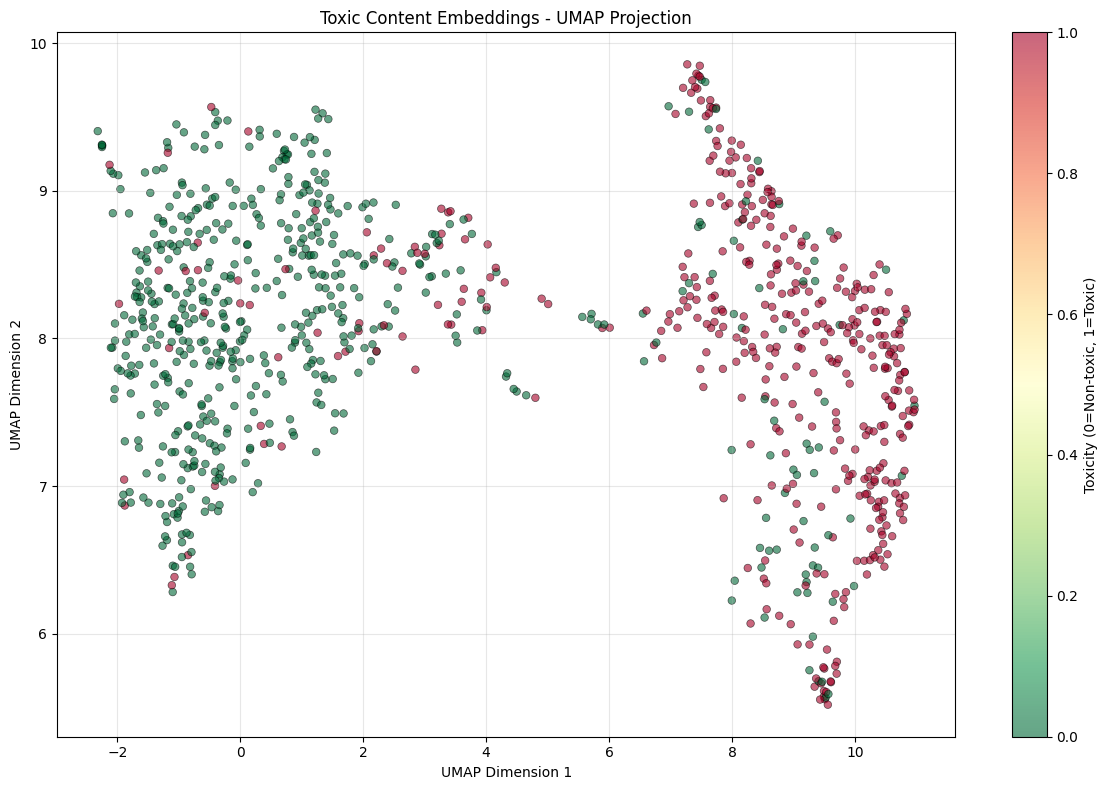

✅ Visualization complete!


In [22]:
# Visualize embeddings using UMAP
try:
    from umap import UMAP
    
    print("🔄 Reducing dimensionality with UMAP...")
    
    # Sample embeddings for visualization
    sample_size = min(1000, len(corpus_embeddings))
    sample_embeddings = corpus_embeddings[:sample_size].cpu().numpy()
    sample_labels = corpus_labels[:sample_size]
    
    # Apply UMAP
    reducer = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    embedding_2d = reducer.fit_transform(sample_embeddings)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    scatter = ax.scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        c=sample_labels,
        cmap='RdYlGn_r',
        alpha=0.6,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    
    plt.colorbar(scatter, label='Toxicity (0=Non-toxic, 1=Toxic)', ax=ax)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title('Toxic Content Embeddings - UMAP Projection')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualization complete!")
    
except ImportError:
    print("⚠️ UMAP not installed. Run: pip install umap-learn")

## 10. Test Semantic Search

In [18]:
# Test semantic search with queries
test_queries = [
    "orang bodoh dan tidak berguna",
    "bangsat tolol goblok",
    "terima kasih banyak",
    "saya sangat menghargai bantuan anda"
]

print("🔍 Testing Semantic Search:\n")
print("=" * 80)

for query in test_queries:
    print(f"\n📝 Query: '{query}'")
    print("-" * 80)
    
    # Encode query
    query_embedding = trained_encoder.encode([query], show_progress=False)
    
    # Compute similarities
    similarities = cos_sim(query_embedding, corpus_embeddings[0])
    
    # Get top-5
    top_5_indices = similarities.argsort(descending=True)[:5]
    
    print("\nTop 5 Similar Texts:")
    for i, idx in enumerate(top_5_indices.cpu().numpy(), 1):
        similar_text = corpus_texts[idx]
        score = similarities[idx].item()
        label = "TOXIC" if corpus_labels[idx] == 1 else "NON-TOXIC"
        
        print(f"\n  {i}. [{label}] (score: {score:.4f})")
        print(f"     {similar_text[:100]}...")

print("\n" + "=" * 80)

🔍 Testing Semantic Search:


📝 Query: 'orang bodoh dan tidak berguna'
--------------------------------------------------------------------------------

Top 5 Similar Texts:

  1. [TOXIC] (score: 0.4881)
     USER Alay tai kyk bocah sd lol'...

📝 Query: 'bangsat tolol goblok'
--------------------------------------------------------------------------------

Top 5 Similar Texts:

  1. [TOXIC] (score: 0.5696)
     USER Alay tai kyk bocah sd lol'...

📝 Query: 'terima kasih banyak'
--------------------------------------------------------------------------------

Top 5 Similar Texts:

  1. [TOXIC] (score: -0.0561)
     USER Alay tai kyk bocah sd lol'...

📝 Query: 'saya sangat menghargai bantuan anda'
--------------------------------------------------------------------------------

Top 5 Similar Texts:

  1. [TOXIC] (score: -0.1297)
     USER Alay tai kyk bocah sd lol'...



## 11. Compare Before/After Training

In [19]:
# Load base model for comparison
print("🔄 Loading base model for comparison...")
base_encoder = load_encoder(
    model_name_or_path=config.model.base_model,
    max_seq_length=config.model.max_seq_length
)

# Test pairs
text_pairs = [
    ("dasar bodoh goblok", "bangsat tolol anjing"),  # Both toxic
    ("terima kasih banyak", "saya sangat berterima kasih"),  # Both non-toxic
    ("dasar bodoh", "terima kasih"),  # Toxic vs non-toxic
]

print("\n📊 Similarity Comparison (Before vs After Training):\n")
print("=" * 80)

for text1, text2 in text_pairs:
    # Base model
    base_emb = base_encoder.encode([text1, text2], show_progress=False)
    base_sim = cos_sim(base_emb[0:1], base_emb[1:2]).item()
    
    # Fine-tuned model
    tuned_emb = trained_encoder.encode([text1, text2], show_progress=False)
    tuned_sim = cos_sim(tuned_emb[0:1], tuned_emb[1:2]).item()
    
    print(f"\nText 1: '{text1}'")
    print(f"Text 2: '{text2}'")
    print(f"  Base similarity:       {base_sim:.4f}")
    print(f"  Fine-tuned similarity: {tuned_sim:.4f}")
    print(f"  Improvement:           {tuned_sim - base_sim:+.4f}")

print("\n" + "=" * 80)

2025-11-24 11:45:42 | INFO     | toxic_search.models.encoder:load_encoder - Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


🔄 Loading base model for comparison...


2025-11-24 11:45:45 | INFO     | toxic_search.models.encoder:load_encoder - Encoder loaded: dim=768, device=cuda



📊 Similarity Comparison (Before vs After Training):


Text 1: 'dasar bodoh goblok'
Text 2: 'bangsat tolol anjing'
  Base similarity:       0.8452
  Fine-tuned similarity: 0.9725
  Improvement:           +0.1273

Text 1: 'terima kasih banyak'
Text 2: 'saya sangat berterima kasih'
  Base similarity:       0.9127
  Fine-tuned similarity: 0.9564
  Improvement:           +0.0437

Text 1: 'dasar bodoh'
Text 2: 'terima kasih'
  Base similarity:       0.3230
  Fine-tuned similarity: -0.3254
  Improvement:           -0.6484



## 12. Summary and Next Steps

In [20]:
print("\n" + "=" * 80)
print("🎯 TRAINING SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset:")
print(f"  Total samples: {len(df):,}")
print(f"  Train triplets: {len(train_triplets):,}")
print(f"  Val triplets: {len(val_triplets):,}")
print(f"  Test triplets: {len(test_triplets):,}")

print(f"\n🤖 Model:")
print(f"  Base: {config.model.base_model}")
print(f"  Embedding dim: {trained_encoder.embedding_dim}")
print(f"  Device: {trained_encoder.device}")

print(f"\n📈 Performance:")
for metric, value in metrics.items():
    print(f"  {metric}: {value:.4f}")

print(f"\n💾 Saved Model:")
print(f"  Path: {OUTPUT_PATH}")
print(f"  Files: {[f.name for f in OUTPUT_PATH.iterdir()]}")

print(f"\n🔧 Next Steps:")
print(f"  1. Build vector index: python -m toxic_search.index.builder")
print(f"  2. Start API server: python -m toxic_search.api.main")
print(f"  3. Launch UI: streamlit run src/toxic_search/ui/app.py")
print(f"  4. Test search: use /search endpoint or UI")

print("\n" + "=" * 80)
print("✅ ALL TASKS COMPLETED!")
print("=" * 80)


🎯 TRAINING SUMMARY

📊 Dataset:
  Total samples: 14,306
  Train triplets: 11,444
  Val triplets: 1,431
  Test triplets: 1,431

🤖 Model:
  Base: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  Embedding dim: 768
  Device: cuda

📈 Performance:
  precision@1: 1.0000
  precision@5: 0.8780
  precision@10: 0.8596
  precision@20: 0.8545
  recall@1: 0.0028
  recall@5: 0.0121
  recall@10: 0.0237
  recall@20: 0.0471
  MAP: 0.9257
  MRR: 1.0000

💾 Saved Model:
  Path: /indonesian-hate-speech-detection-main/models/toxic_search_finetuned
  Files: ['config_sentence_transformers.json', 'config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'tokenizer.json', 'sentence_bert_config.json', '1_Pooling', 'modules.json', 'README.md']

🔧 Next Steps:
  1. Build vector index: python -m toxic_search.index.builder
  2. Start API server: python -m toxic_search.api.main
  3. Launch UI: streamlit run src/toxic_search/ui/app.py
  4. Test search: use /search endpoint or 